In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Smartphone.csv")


In [ ]:
#1. exploratory data analysis
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [ ]:
print(df.shape)


(7500, 16)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [ ]:
print(df.isnull().sum())

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64


In [ ]:
#2. descriptive statistics
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [ ]:
df.mean(numeric_only=True)

,0
age,26.568800
daily_screen_time_hours,7.499912
social_media_hours,3.273484
gaming_hours,2.014183
work_study_hours,3.242420
sleep_hours,6.737561
notifications_per_day,134.257333
app_opens_per_day,97.832400
weekend_screen_time,9.243827
addicted_label,0.707733


In [ ]:
df.var(numeric_only=True)

,0
age,27.009935
daily_screen_time_hours,6.807859
social_media_hours,2.513308
gaming_hours,1.313406
work_study_hours,2.562448
sleep_hours,1.647641
notifications_per_day,4433.812955
app_opens_per_day,2344.820686
weekend_screen_time,7.389051
addicted_label,0.206874


In [ ]:
#3. Data Cleaning and Transformation
# Replace missing values with median
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [ ]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

if 'gender' in df.columns:
    df['gender'] = le.fit_transform(df['gender'])

if 'addiction_level' in df.columns:
    df['addiction_level'] = le.fit_transform(df['addiction_level'])

print("\nData After Cleaning")
print(df.head())


Data After Cleaning
  transaction_id user_id  age  gender  daily_screen_time_hours  \
0       TXN00001  U00001   21       1                     3.23   
1       TXN00002  U00002   24       2                     5.09   
2       TXN00003  U00003   31       2                     6.06   
3       TXN00004  U00004   32       2                     7.83   
4       TXN00005  U00005   25       1                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   

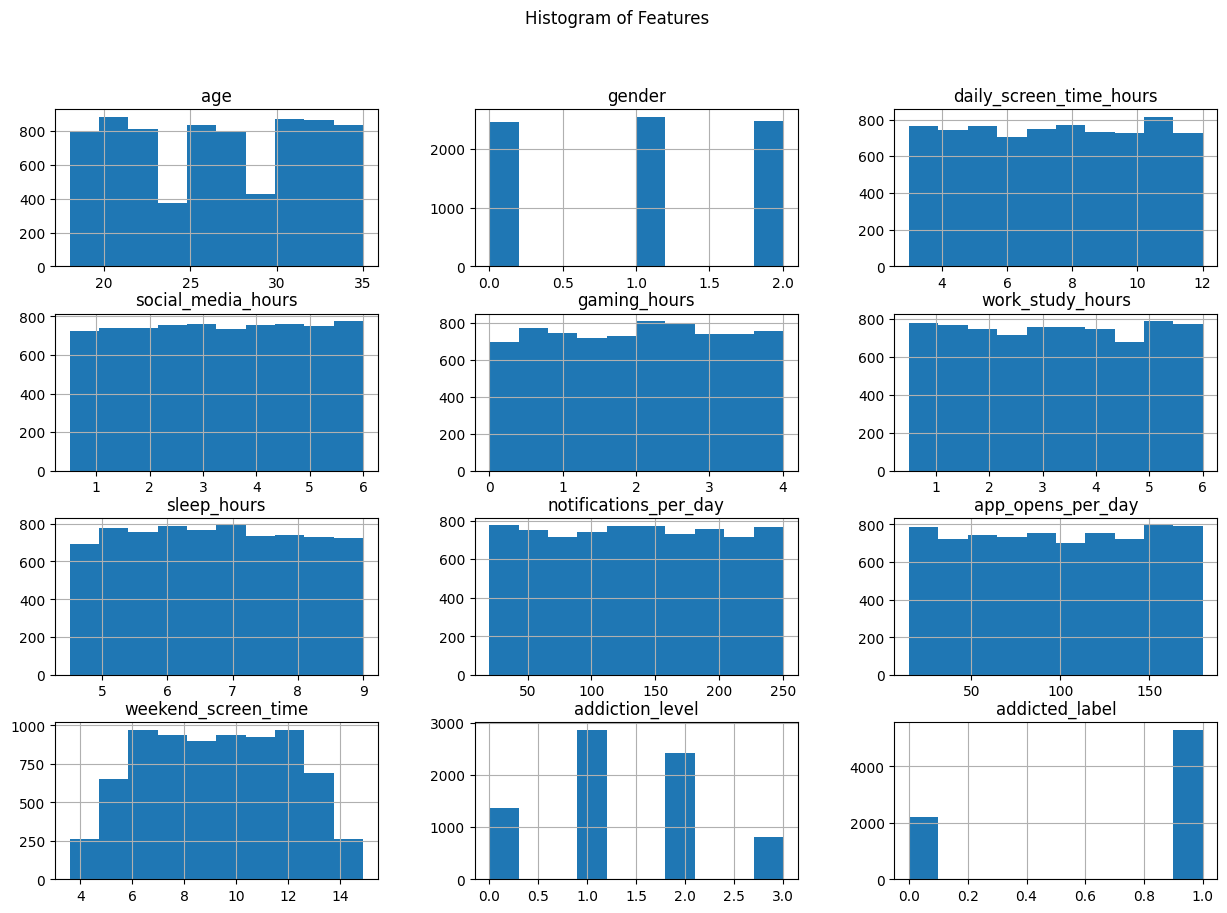

In [ ]:
# 4 Basic Data Visualization
# Histogram
df.hist(figsize=(15,10))
plt.suptitle("Histogram of Features")
plt.show()

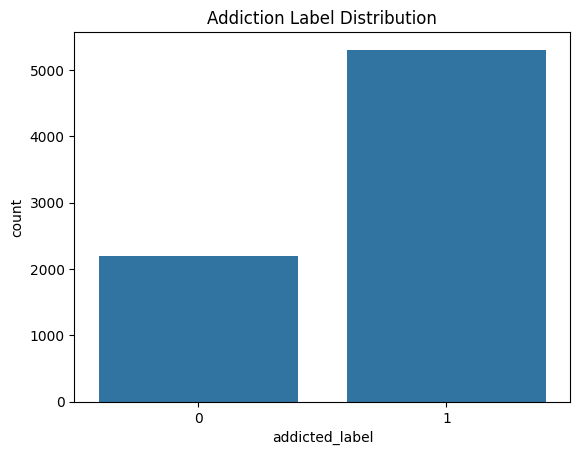

In [ ]:
# Count plot for addiction label
sns.countplot(x='addicted_label', data=df)
plt.title("Addiction Label Distribution")
plt.show()

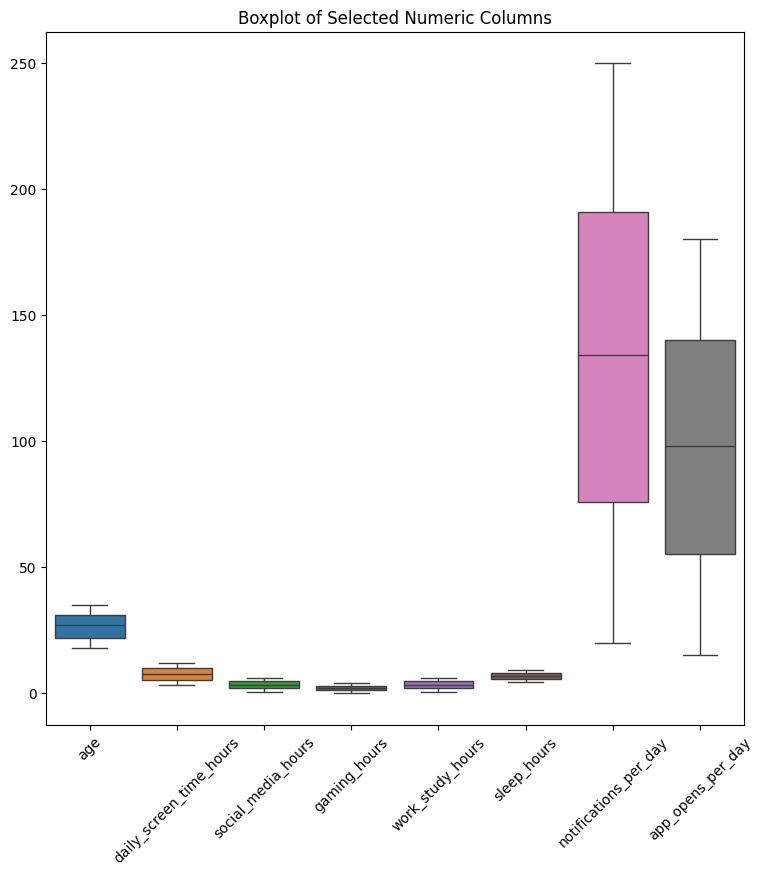

In [ ]:
numeric_columns = ['age','daily_screen_time_hours','social_media_hours','gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day']
plt.figure(figsize=(9,9))
sns.boxplot(data=df[numeric_columns])

plt.title("Boxplot of Selected Numeric Columns")
plt.xticks(rotation=45)
plt.show()

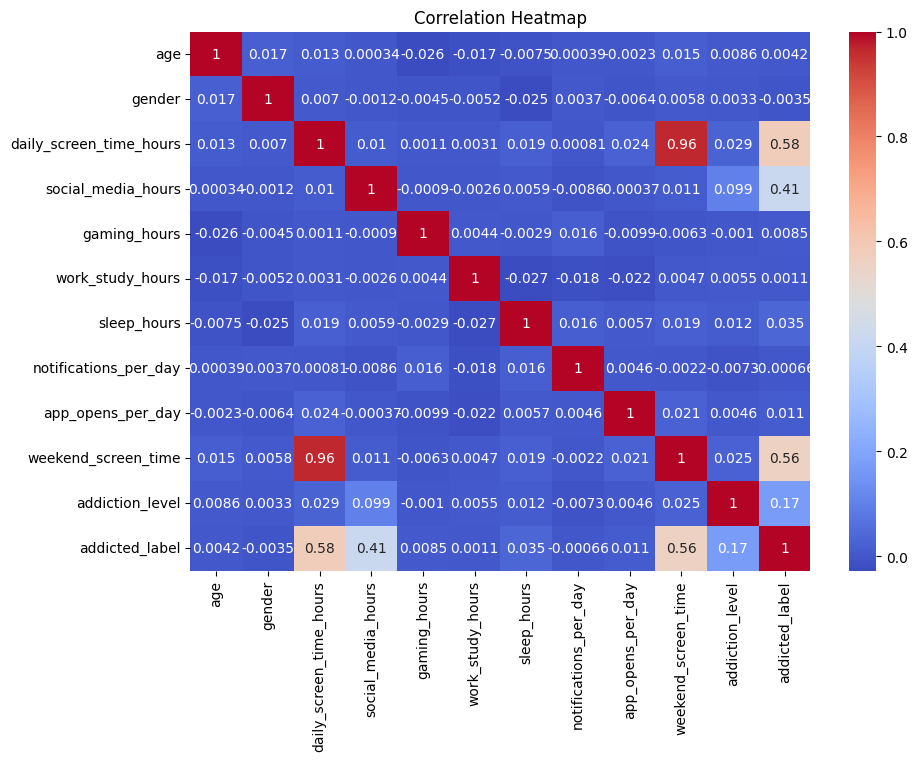

In [ ]:
# 5 Correlation Analysis
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Create age groups
df['age_group'] = pd.cut(df['age'],
                         bins=[10,18,25,35,50],
                         labels=['Teen','Young Adult','Adult','Older'])


In [ ]:
# Average addiction level by age group
age_addiction = df.groupby('age_group')['addiction_level'].mean()

print(age_addiction)


age_group
Teen           1.238095
Young Adult    1.361613
Adult          1.370178
Older               NaN
Name: addiction_level, dtype: float64


/tmp/ipykernel_1113/3114070741.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_addiction = df.groupby('age_group')['addiction_level'].mean()


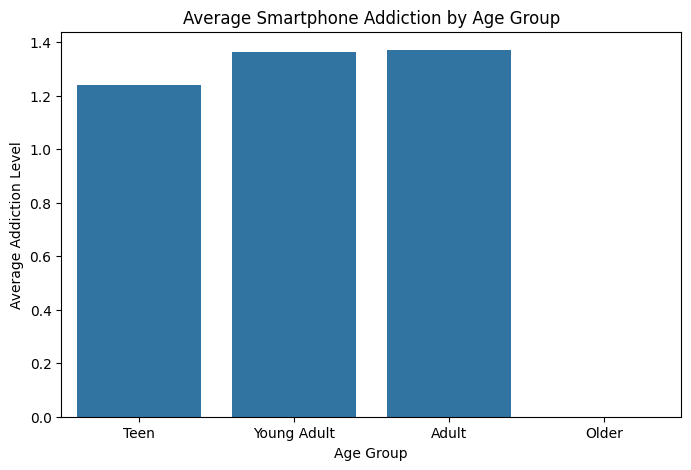

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=age_addiction.index, y=age_addiction.values)

plt.title("Average Smartphone Addiction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Addiction Level")
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)
print(corr[['addiction_level','sleep_hours']])

                         addiction_level  sleep_hours
age                             0.008606    -0.007462
gender                          0.003274    -0.025167
daily_screen_time_hours         0.028872     0.019343
social_media_hours              0.098975     0.005947
gaming_hours                   -0.001036    -0.002874
work_study_hours                0.005518    -0.027150
sleep_hours                     0.012440     1.000000
notifications_per_day          -0.007257     0.016273
app_opens_per_day               0.004610     0.005692
weekend_screen_time             0.024732     0.018933
addiction_level                 1.000000     0.012440
addicted_label                  0.170119     0.035496


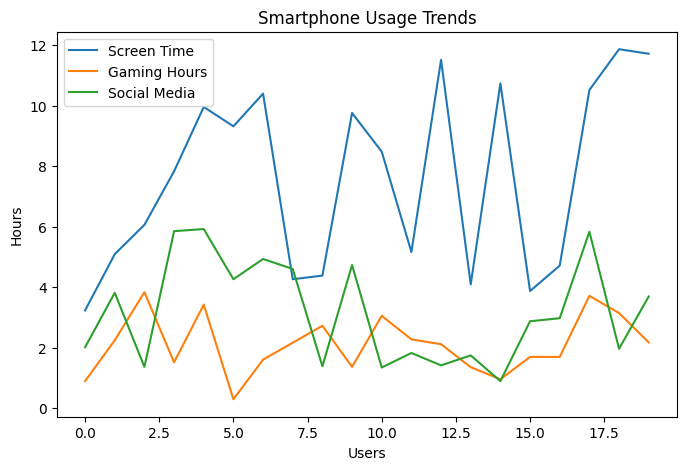

In [ ]:
# Select few variables
data = df[['daily_screen_time_hours','gaming_hours','social_media_hours']].head(20)

# Line plot
plt.figure(figsize=(8,5))

plt.plot(data['daily_screen_time_hours'], label='Screen Time')
plt.plot(data['gaming_hours'], label='Gaming Hours')
plt.plot(data['social_media_hours'], label='Social Media')

plt.title("Smartphone Usage Trends")
plt.xlabel("Users")
plt.ylabel("Hours")
plt.legend()

plt.show()

<Axes: ylabel='count'>

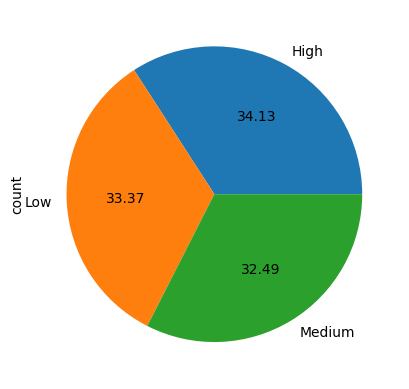

In [ ]:
df['stress_level'].value_counts().plot(kind='pie', autopct='%.2f')

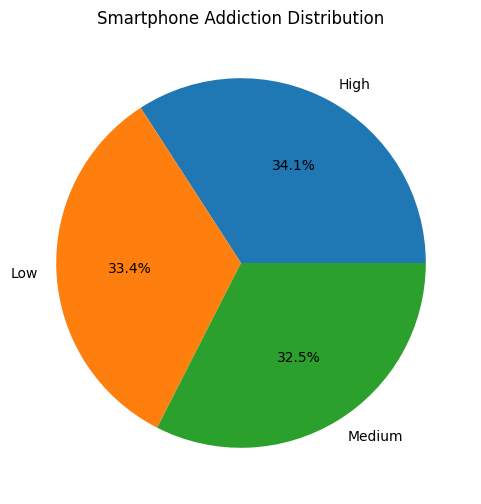

In [ ]:
counts = df['stress_level'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

plt.title("Smartphone Addiction Distribution")
plt.show()

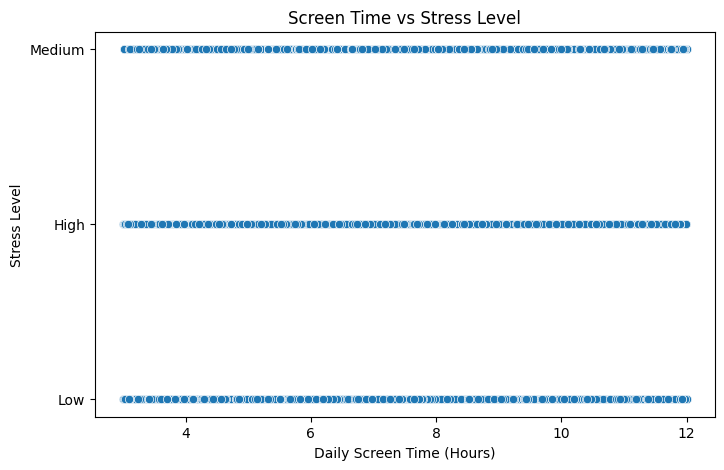

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='daily_screen_time_hours', y='stress_level', data=df)

plt.title("Screen Time vs Stress Level")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Stress Level")

plt.show()

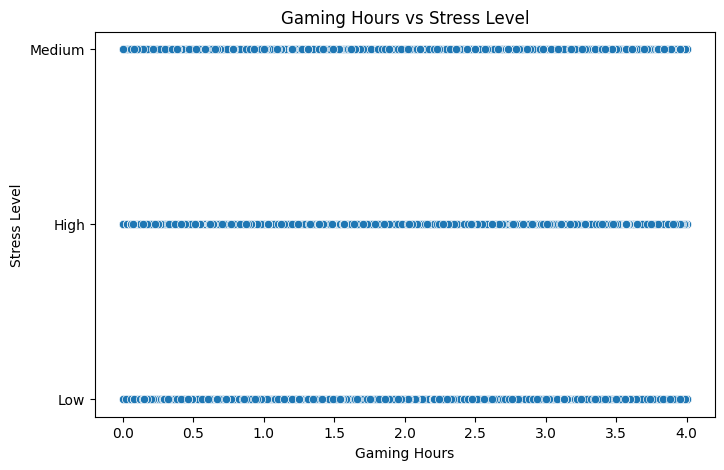

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='gaming_hours', y='stress_level', data=df)

plt.title("Gaming Hours vs Stress Level")
plt.xlabel("Gaming Hours")
plt.ylabel("Stress Level")

plt.show()

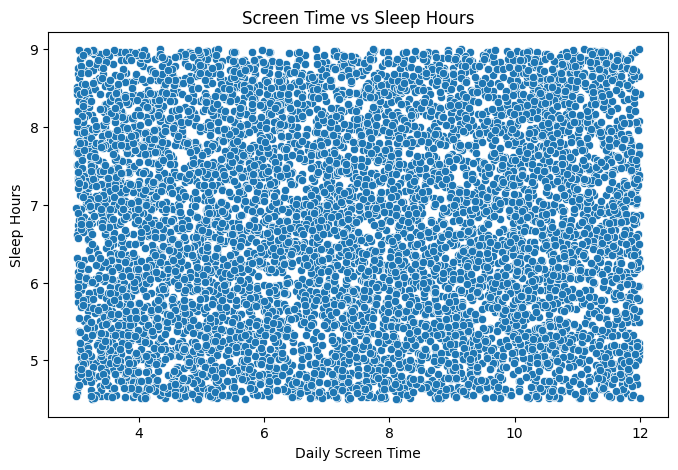

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='daily_screen_time_hours', y='sleep_hours', data=df)

plt.title("Screen Time vs Sleep Hours")
plt.xlabel("Daily Screen Time")
plt.ylabel("Sleep Hours")

plt.show()

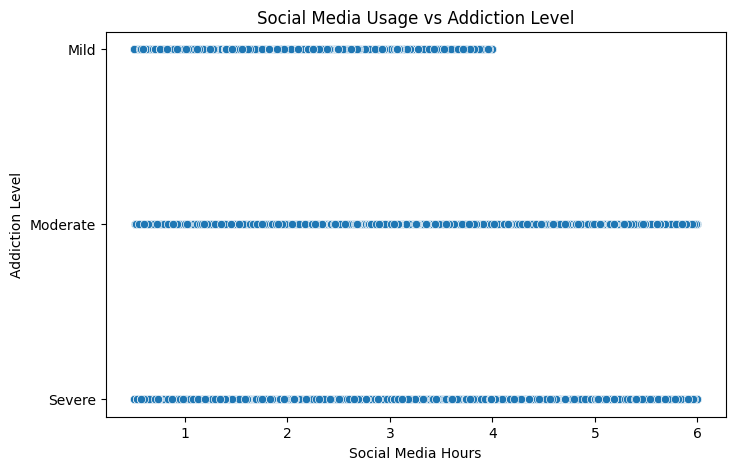

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='social_media_hours', y='addiction_level', data=df)

plt.title("Social Media Usage vs Addiction Level")
plt.xlabel("Social Media Hours")
plt.ylabel("Addiction Level")

plt.show()

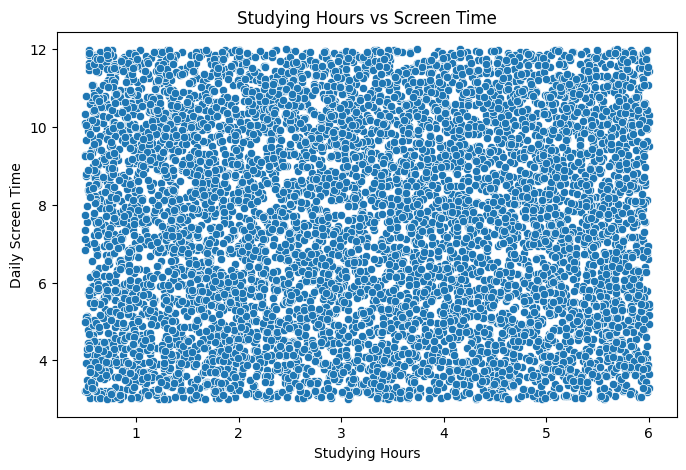

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='work_study_hours', y='daily_screen_time_hours', data=df)

plt.title("Studying Hours vs Screen Time")
plt.xlabel("Studying Hours")
plt.ylabel("Daily Screen Time")

plt.show()

<Axes: xlabel='daily_screen_time_hours', ylabel='stress_level'>

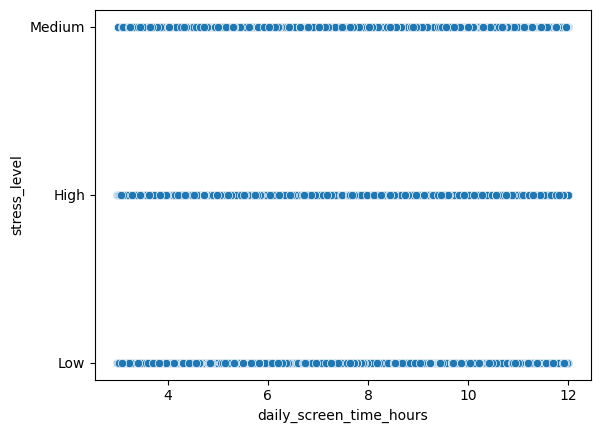

In [ ]:
sns.scatterplot(x= df['daily_screen_time_hours'],y= df['stress_level'])

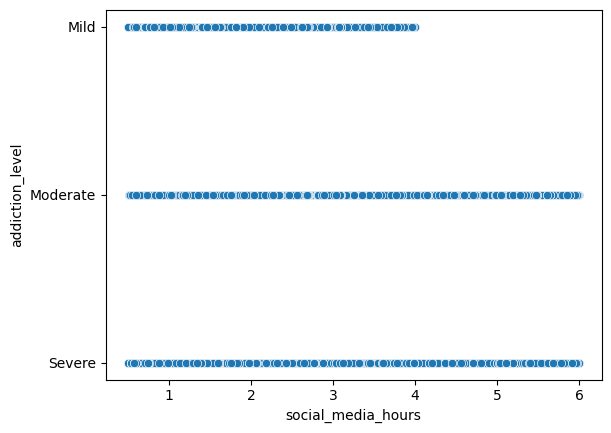

In [ ]:
sns.scatterplot(x='social_media_hours', y='addiction_level', data=df)
plt.show()

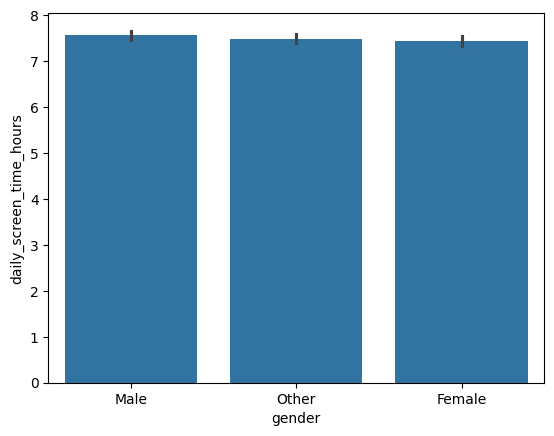

In [ ]:
sns.barplot(x='gender', y='daily_screen_time_hours', data=df)
plt.show()

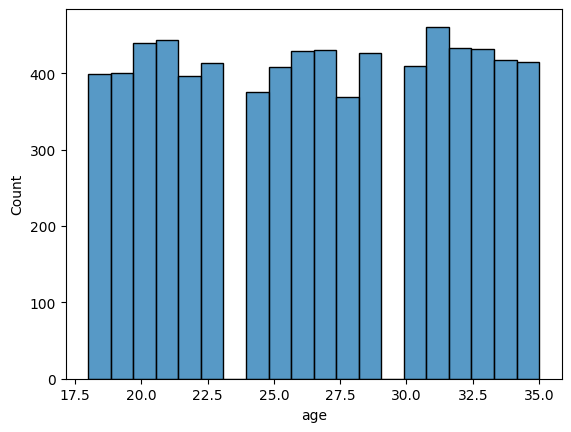

In [ ]:
sns.histplot(df['age'], bins=20)
plt.show()

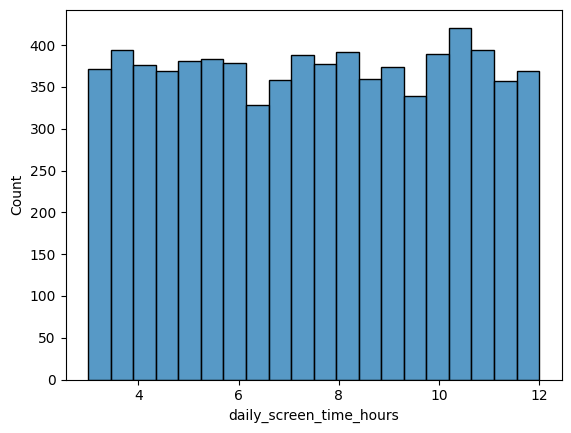

In [ ]:
sns.histplot(df['daily_screen_time_hours'])
plt.show()

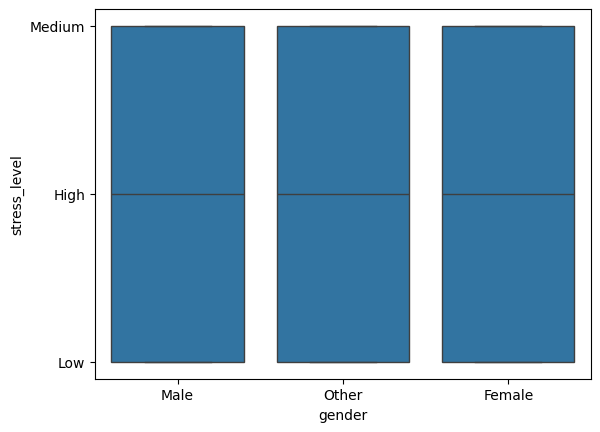

In [ ]:
sns.boxplot(x='gender', y='stress_level', data=df)
plt.show()

In [ ]:
print(df.corr(numeric_only=True)['social_media_hours'])

age                        0.000342
daily_screen_time_hours    0.010321
social_media_hours         1.000000
gaming_hours              -0.000902
work_study_hours          -0.002580
sleep_hours                0.005947
notifications_per_day     -0.008593
app_opens_per_day         -0.000371
weekend_screen_time        0.011404
addicted_label             0.414244
Name: social_media_hours, dtype: float64


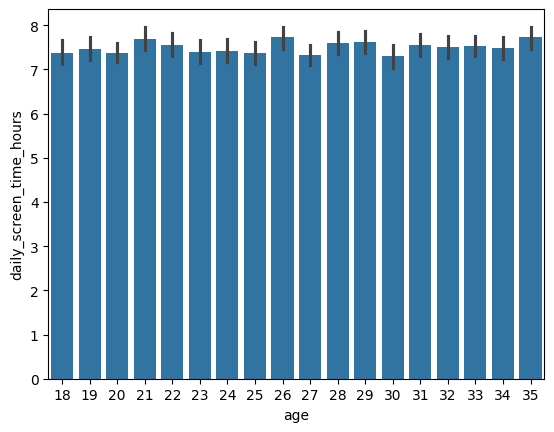

In [ ]:
sns.barplot(x='age', y='daily_screen_time_hours', data=df)
plt.show()

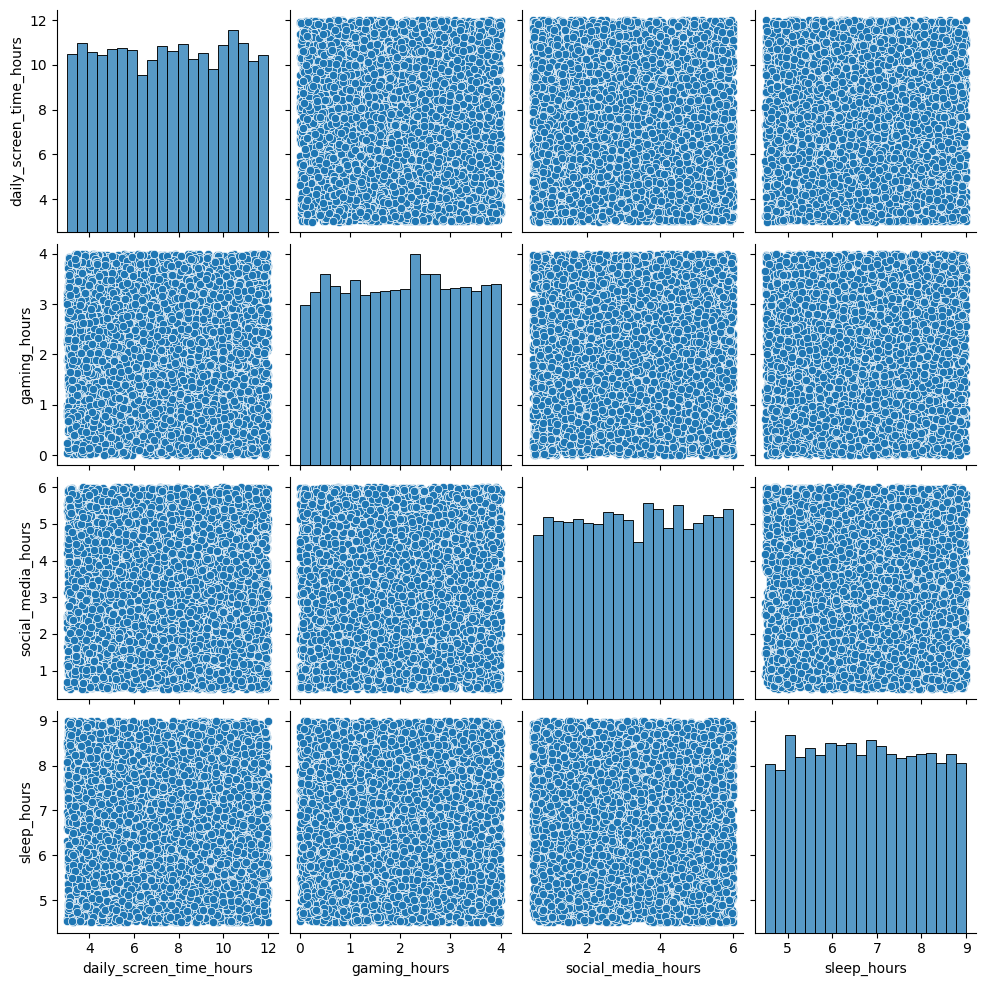

In [ ]:
sns.pairplot(df[['daily_screen_time_hours','gaming_hours','social_media_hours','sleep_hours','stress_level']])
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

features = ['daily_screen_time_hours','gaming_hours','social_media_hours']

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])
